# Bank Marketing — Classificação binária (adesão a depósito a prazo)

Notebook do domínio **Bank Marketing** do Trabalho A2 de Data Science.

**Classe positiva do domínio:** `yes` (a pergunta que o modelo responde é *"este cliente vai aderir ao depósito a prazo?"*).

Fonte dos dados: Moro, Cortez & Rita (2014), UCI Machine Learning Repository — Bank Marketing Data Set (licença CC BY 4.0).

## 1. Carregamento dos dados e definição da classe positiva

In [1]:
import pandas as pd
import numpy as np

df = pd.read_csv("bank.csv")
df = df.drop(columns=["duration"])
df["target"] = (df["y"] == "yes").astype(int)
df = df.drop(columns=["y"])
df.head()

,age,job,marital,education,default,housing,loan,contact,month,day_of_week,campaign,pdays,previous,poutcome,emp.var.rate,cons.price.idx,cons.conf.idx,euribor3m,nr.employed,target
0,56,housemaid,married,basic.4y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
1,57,services,married,high.school,unknown,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
2,37,services,married,high.school,no,yes,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
3,40,admin.,married,basic.6y,no,no,no,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0
4,56,services,married,high.school,no,no,yes,telephone,may,mon,1,999,0,nonexistent,1.1,93.994,-36.4,4.857,5191.0,0


**Decisão importante:** a coluna `duration` foi removida porque só é conhecida depois que a
ligação termina — usá-la seria vazamento de dado (o próprio dicionário da UCI recomenda a remoção
para um cenário realista de previsão).

## 2. Verificação do balanceamento (item iii)

In [2]:
contagem = df["target"].value_counts().sort_index()
percentual = (contagem / contagem.sum() * 100).round(2)
pd.DataFrame({"qtd": contagem, "%": percentual})

,qtd,%
target,,
0,36548,88.73
1,4640,11.27


~11% de adesão — desbalanceamento moderado. Vamos usar AUC-PR como métrica-alvo principal, já que
acurácia sozinha seria enganosa (um modelo que sempre prevê "não" já acertaria ~89%).

## 3. Separação treino / validação / teste (item iv) e identificação de colunas categóricas/numéricas

In [3]:
from sklearn.model_selection import train_test_split

colunas_categoricas = ["job", "marital", "education", "default", "housing", "loan",
                        "contact", "month", "day_of_week", "poutcome"]
colunas_numericas = ["age", "campaign", "pdays", "previous", "emp.var.rate",
                      "cons.price.idx", "cons.conf.idx", "euribor3m", "nr.employed"]

X = df[colunas_categoricas + colunas_numericas]
y = df["target"].values

X_train_raw, X_temp_raw, y_train, y_temp = train_test_split(X, y, test_size=0.4, stratify=y, random_state=42)
X_val_raw, X_test_raw, y_val, y_test = train_test_split(X_temp_raw, y_temp, test_size=0.5, stratify=y_temp, random_state=42)

print(f"Treino={len(y_train)}  Validação={len(y_val)}  Teste={len(y_test)}")
print(f"Proporção positiva -> treino={y_train.mean():.3f}  val={y_val.mean():.3f}  teste={y_test.mean():.3f}")

Treino=24712  Validação=8238  Teste=8238
Proporção positiva -> treino=0.113  val=0.113  teste=0.113


## 4. Pré-processamento (item v): One-Hot Encoding + padronização

`fit` roda só no treino; validação e teste passam apenas por `transform`.

In [4]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

pre = ColumnTransformer([
    ("cat", OneHotEncoder(handle_unknown="ignore"), colunas_categoricas),
    ("num", StandardScaler(), colunas_numericas),
])
X_train = pre.fit_transform(X_train_raw)
X_val = pre.transform(X_val_raw)
X_test = pre.transform(X_test_raw)
if hasattr(X_train, "toarray"):
    X_train, X_val, X_test = X_train.toarray(), X_val.toarray(), X_test.toarray()
feature_names = pre.get_feature_names_out()
X_train.shape

(24712, 62)

## 5. Comparação de pelo menos 3 algoritmos (item vi)

Mesma metodologia do domínio Spam: Regressão Logística, Random Forest e Hist Gradient Boosting,
ajustados por `GridSearchCV` (cv=3) otimizando AUC-PR, selecionados pelo desempenho na validação.

In [5]:
from sklearn.model_selection import GridSearchCV
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import average_precision_score, roc_auc_score

grids = {
    "Regressão Logística": (LogisticRegression(max_iter=2000, random_state=42),
                             {"C": [0.1, 1, 10], "class_weight": [None, "balanced"]}),
    "Random Forest": (RandomForestClassifier(random_state=42, n_jobs=1),
                       {"n_estimators": [150], "max_depth": [None, 12], "class_weight": [None, "balanced"]}),
    "Hist Gradient Boosting": (HistGradientBoostingClassifier(random_state=42),
                                {"max_iter": [100], "max_depth": [None, 10], "learning_rate": [0.1]}),
}

linhas = []
modelos_ajustados = {}
for nome, (estimador, grade) in grids.items():
    busca = GridSearchCV(estimador, grade, scoring="average_precision", cv=3, n_jobs=1)
    busca.fit(X_train, y_train)
    melhor = busca.best_estimator_
    prob_val = melhor.predict_proba(X_val)[:, 1]
    linhas.append({
        "Algoritmo": nome,
        "Melhores hiperparâmetros": busca.best_params_,
        "AUC-PR (validação)": round(average_precision_score(y_val, prob_val), 4),
        "AUC-ROC (validação)": round(roc_auc_score(y_val, prob_val), 4),
    })
    modelos_ajustados[nome] = melhor

resultados = pd.DataFrame(linhas).sort_values("AUC-PR (validação)", ascending=False).reset_index(drop=True)
melhor_nome = resultados.iloc[0]["Algoritmo"]
melhor_modelo = modelos_ajustados[melhor_nome]
resultados

,Algoritmo,Melhores hiperparâmetros,AUC-PR (validação),AUC-ROC (validação)
0,Hist Gradient Boosting,"{'learning_rate': 0.1, 'max_depth': None, 'max...",0.4864,0.8103
1,Random Forest,"{'class_weight': None, 'max_depth': 12, 'n_est...",0.4806,0.8061
2,Regressão Logística,"{'C': 1, 'class_weight': None}",0.4698,0.8005


*(preencher aqui a leitura dos resultados com as próprias palavras da equipe)*

## 6. Avaliação dos 3 algoritmos e do melhor modelo no conjunto de teste (item vii)

In [6]:
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                              confusion_matrix, roc_curve, precision_recall_curve, auc)

def metricas_completas(modelos, X, y, limiar=0.5):
    linhas = []
    for nome, modelo in modelos.items():
        prob = modelo.predict_proba(X)[:, 1]
        pred = (prob >= limiar).astype(int)
        linhas.append({
            "Algoritmo": nome, "Threshold": limiar,
            "Acurácia": round(accuracy_score(y, pred), 4),
            "Precisão": round(precision_score(y, pred, zero_division=0), 4),
            "Recall": round(recall_score(y, pred, zero_division=0), 4),
            "F1": round(f1_score(y, pred, zero_division=0), 4),
            "AUC-ROC": round(roc_auc_score(y, prob), 4),
            "AUC-PR (Average Precision)": round(average_precision_score(y, prob), 4),
            "Matriz de confusão [[TN FP][FN TP]]": confusion_matrix(y, pred).tolist(),
        })
    return pd.DataFrame(linhas)

tabela_val_3algoritmos = metricas_completas(modelos_ajustados, X_val, y_val)
tabela_val_3algoritmos

,Algoritmo,Threshold,Acurácia,Precisão,Recall,F1,AUC-ROC,AUC-PR (Average Precision),Matriz de confusão [[TN FP][FN TP]]
0,Regressão Logística,0.5,0.9016,0.6757,0.2425,0.3569,0.8005,0.4698,"[[7202, 108], [703, 225]]"
1,Random Forest,0.5,0.9022,0.6837,0.2446,0.3603,0.8061,0.4806,"[[7205, 105], [701, 227]]"
2,Hist Gradient Boosting,0.5,0.9023,0.6762,0.2543,0.3696,0.8103,0.4864,"[[7197, 113], [692, 236]]"


In [7]:
import matplotlib.pyplot as plt

proba_test = melhor_modelo.predict_proba(X_test)[:, 1]
pred_test = (proba_test >= 0.5).astype(int)

print(f"Melhor modelo: {melhor_nome}")
print(f"Acurácia: {accuracy_score(y_test, pred_test):.4f}")
print(f"Precisão: {precision_score(y_test, pred_test):.4f}")
print(f"Recall: {recall_score(y_test, pred_test):.4f}")
print(f"F1: {f1_score(y_test, pred_test):.4f}")
print(f"AUC-ROC: {roc_auc_score(y_test, proba_test):.4f}")
print(f"AUC-PR (Average Precision): {average_precision_score(y_test, proba_test):.4f}")
print("Matriz de confusão [[TN FP][FN TP]]:")
print(confusion_matrix(y_test, pred_test))

Melhor modelo: Hist Gradient Boosting
Acurácia: 0.9022
Precisão: 0.6871
Recall: 0.2414
F1: 0.3573
AUC-ROC: 0.8149
AUC-PR (Average Precision): 0.4908
Matriz de confusão [[TN FP][FN TP]]:
[[7208  102]
 [ 704  224]]


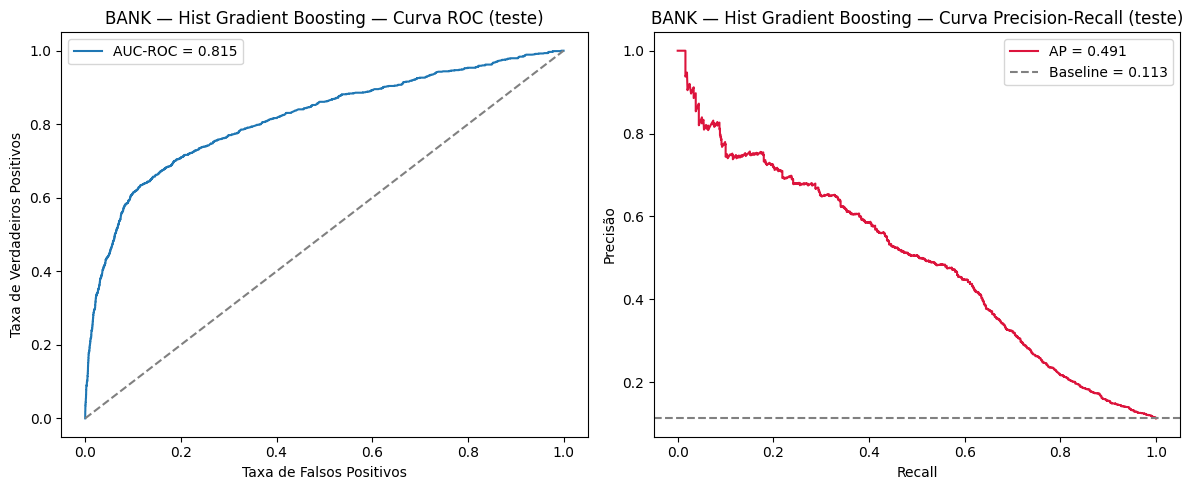

In [8]:
fpr, tpr, _ = roc_curve(y_test, proba_test)
prec, rec, _ = precision_recall_curve(y_test, proba_test)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].plot(fpr, tpr, label=f"AUC-ROC = {auc(fpr, tpr):.3f}")
axes[0].plot([0, 1], [0, 1], "--", color="gray")
axes[0].set_xlabel("Taxa de Falsos Positivos"); axes[0].set_ylabel("Taxa de Verdadeiros Positivos")
axes[0].set_title(f"BANK — {melhor_nome} — Curva ROC (teste)"); axes[0].legend()

axes[1].plot(rec, prec, color="crimson", label=f"AP = {average_precision_score(y_test, proba_test):.3f}")
axes[1].axhline(y_test.mean(), linestyle="--", color="gray", label=f"Baseline = {y_test.mean():.3f}")
axes[1].set_xlabel("Recall"); axes[1].set_ylabel("Precisão")
axes[1].set_title(f"BANK — {melhor_nome} — Curva Precision-Recall (teste)"); axes[1].legend()
fig.tight_layout()
plt.show()

A área sob a PR reportada é a **Average Precision (AP)**, distinta da integração trapezoidal simples
sobre a curva.

*(preencher aqui a leitura dos números com as próprias palavras da equipe)*

## 7. SHAP — explicação do melhor modelo (item viii)

/usr/local/lib/python3.12/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


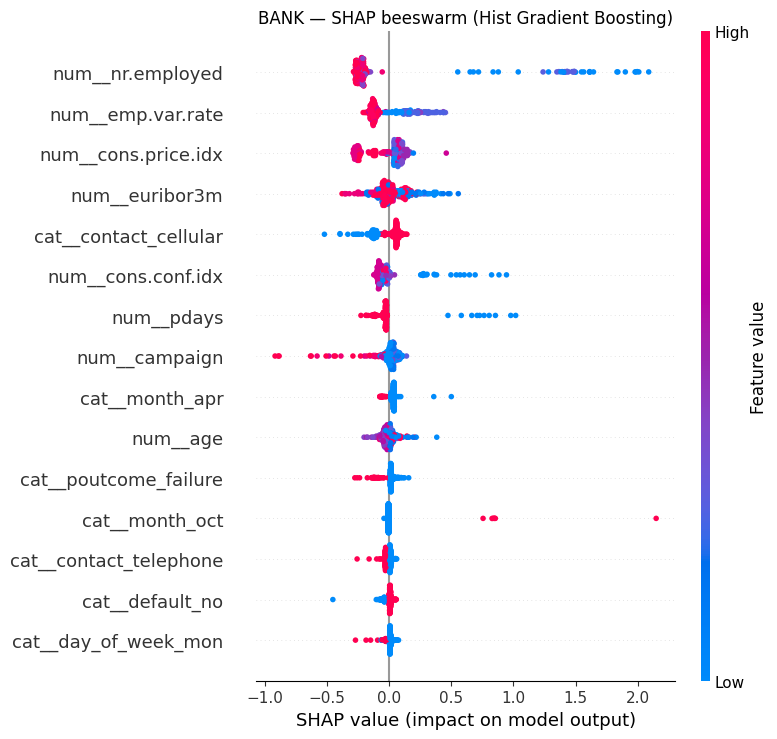

In [9]:
import shap

idx_amostra = np.random.default_rng(42).choice(len(X_test), size=min(300, len(X_test)), replace=False)
amostra = X_test[idx_amostra]

if melhor_nome == "Regressão Logística":
    fundo = shap.sample(amostra, min(200, amostra.shape[0]))
    explainer = shap.LinearExplainer(melhor_modelo, fundo)
    valores_shap = explainer.shap_values(amostra)
else:
    explainer = shap.TreeExplainer(melhor_modelo)
    valores_shap = explainer.shap_values(amostra)
    if isinstance(valores_shap, list):
        valores_shap = valores_shap[1]
    if valores_shap.ndim == 3:
        valores_shap = valores_shap[:, :, 1]

shap.summary_plot(valores_shap, amostra, feature_names=feature_names, max_display=15, show=False)
plt.title(f"BANK — SHAP beeswarm ({melhor_nome})")
plt.tight_layout()
plt.show()

*(preencher aqui a leitura do gráfico SHAP com as próprias palavras da equipe)*

## 8. Programa da Parte 1 — histograma e faixas de decisão (reutilizável)

Mesma função do notebook de Spam — reutilizável para qualquer domínio.

In [10]:
def analisar_faixas_decisao(y_real, y_prob, largura_intervalo=10, t1=None, t2=None,
                             classe_positiva=1, titulo="Distribuição de Probabilidades"):
    y_real = np.asarray(y_real)
    y_prob = np.asarray(y_prob, dtype=float)
    prob_pct = y_prob * 100 if y_prob.max() <= 1.0 else y_prob

    n_faixas = int(round(100 / largura_intervalo))
    bordas = np.linspace(0, 100, n_faixas + 1)
    todas_contagens, _ = np.histogram(prob_pct, bins=bordas)
    positivos_mask = (y_real == classe_positiva)
    positivos_contagens, _ = np.histogram(prob_pct[positivos_mask], bins=bordas)

    total = len(prob_pct)
    todas_pct = todas_contagens / total * 100
    positivos_pct = positivos_contagens / total * 100

    fig, ax = plt.subplots(figsize=(10, 6))
    centros = (bordas[:-1] + bordas[1:]) / 2
    largura = largura_intervalo * 0.9
    ax.bar(centros, todas_pct, width=largura, color="steelblue", alpha=0.6, label="Todas as instâncias", edgecolor="black")
    ax.bar(centros, positivos_pct, width=largura * 0.6, color="crimson", alpha=0.8,
           label=f"Instâncias com rótulo real = {classe_positiva}", edgecolor="black")
    ax.set_ylim(top=ax.get_ylim()[1] * 1.15)

    if t1 is not None:
        t1_pct = t1 * 100 if t1 <= 1.0 else t1
        ax.axvline(t1_pct, color="black", linestyle="--")
        ax.text(t1_pct, ax.get_ylim()[1] * 0.93, f" t1={t1_pct:.1f}% ", rotation=90, va="top",
                ha="left" if t1_pct < 50 else "right", fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))
    if t2 is not None:
        t2_pct = t2 * 100 if t2 <= 1.0 else t2
        ax.axvline(t2_pct, color="black", linestyle="--")
        ax.text(t2_pct, ax.get_ylim()[1] * 0.93, f" t2={t2_pct:.1f}% ", rotation=90, va="top",
                ha="left" if t2_pct < 50 else "right", fontsize=9,
                bbox=dict(facecolor="white", edgecolor="none", alpha=0.8, pad=1))

    ax.set_xlabel("Probabilidade estimada da classe positiva (%)")
    ax.set_ylabel("Percentual de instâncias (%)")
    ax.set_title(titulo)
    ax.set_xlim(0, 100)
    ax.legend()
    ax.grid(axis="y", alpha=0.3)
    fig.tight_layout()

    tabela_faixas = None
    resumo_erros = None
    if t1 is not None and t2 is not None:
        t1_pct = t1 * 100 if t1 <= 1.0 else t1
        t2_pct = t2 * 100 if t2 <= 1.0 else t2
        faixa_neg = prob_pct < t1_pct
        faixa_manual = (prob_pct >= t1_pct) & (prob_pct < t2_pct)
        faixa_pos = prob_pct >= t2_pct

        linhas = []
        for nome, mascara in [("Negativa automática", faixa_neg), ("Análise manual", faixa_manual), ("Positiva automática", faixa_pos)]:
            n_faixa = int(mascara.sum())
            n_pos = int((mascara & positivos_mask).sum())
            n_neg = n_faixa - n_pos
            linhas.append({
                "Faixa": nome,
                f"% da população (n={total})": round(n_faixa / total * 100, 2),
                "Qtd positivos": n_pos,
                "% positivos na faixa": round(n_pos / n_faixa * 100, 2) if n_faixa else 0.0,
                "Qtd negativos": n_neg,
                "% negativos na faixa": round(n_neg / n_faixa * 100, 2) if n_faixa else 0.0,
            })
        tabela_faixas = pd.DataFrame(linhas)

        n_pos_total = int(positivos_mask.sum())
        n_neg_total = total - n_pos_total
        fn = int((positivos_mask & faixa_neg).sum())
        fp = int((~positivos_mask & faixa_pos).sum())
        resumo_erros = pd.DataFrame([{
            "Positivos → negativo automático (%)": round(fn / n_pos_total * 100, 2) if n_pos_total else 0.0,
            "Denominador (positivos reais)": n_pos_total,
            "Negativos → positivo automático (%)": round(fp / n_neg_total * 100, 2) if n_neg_total else 0.0,
            "Denominador (negativos reais)": n_neg_total,
        }])

    return fig, tabela_faixas, resumo_erros

## 9. Escolha dos pontos de corte na validação e aplicação ao teste (item ix)

t1=0.0596  t2=0.3069


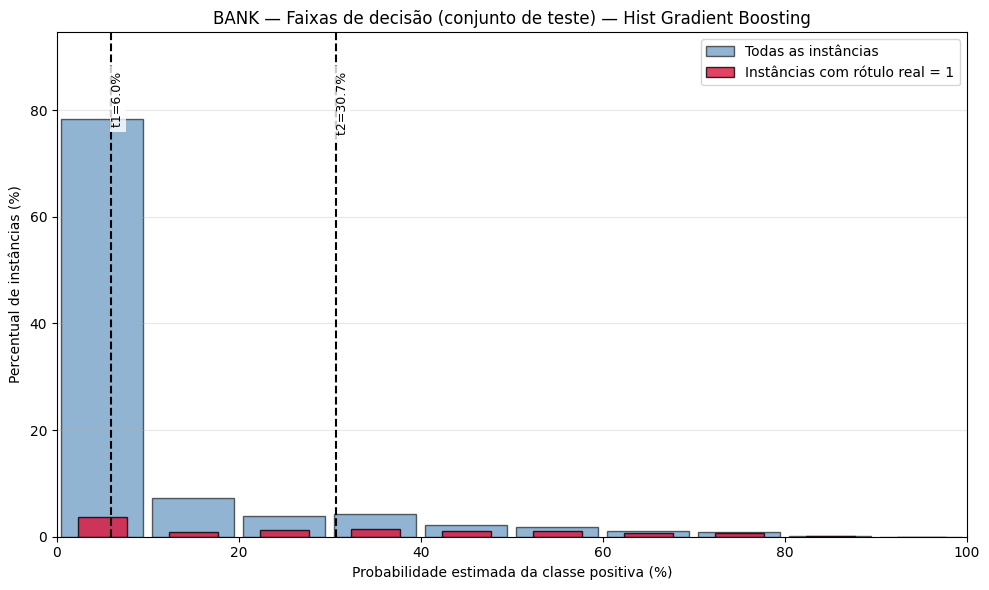

In [11]:
prob_val_melhor = melhor_modelo.predict_proba(X_val)[:, 1]
t1, t2 = np.quantile(prob_val_melhor, [0.5, 0.9])
print(f"t1={t1:.4f}  t2={t2:.4f}")

fig, tabela_faixas, resumo_erros = analisar_faixas_decisao(
    y_test, proba_test, largura_intervalo=10, t1=t1, t2=t2,
    titulo=f"BANK — Faixas de decisão (conjunto de teste) — {melhor_nome}")
plt.show()

In [12]:
print(tabela_faixas.to_string(index=False))

              Faixa  % da população (n=8238)  Qtd positivos  % positivos na faixa  Qtd negativos  % negativos na faixa
Negativa automática                    50.16            148                  3.58           3984                 96.42
     Análise manual                    39.74            349                 10.66           2925                 89.34
Positiva automática                    10.10            431                 51.80            401                 48.20


In [13]:
print(resumo_erros.to_string(index=False))

 Positivos → negativo automático (%)  Denominador (positivos reais)  Negativos → positivo automático (%)  Denominador (negativos reais)
                               15.95                            928                                 5.49                           7310


*(preencher aqui a política de triagem e a justificativa da equipe para t1/t2)*